<a href="https://colab.research.google.com/github/sagara-pathum/Skit-learn/blob/main/7_scaled_predictions_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [40]:
# ok first of all we need to make a fuction for plotting some charts .
# for that you need to understand the following
# pyplot figure and subplot
# numpy aixs and size
# numpy concatanate
# numpy random

# so refer following links if you need to recall or learn anything. they explain them very clearly.

# https://www.geeksforgeeks.org/python/matplotlib-pyplot-figure-in-python/
# https://www.w3schools.com/python/numpy/numpy_array_join.asp
# https://www.w3schools.com/python/numpy/trypython.asp?filename=demo_numpy_array_join2
# https://www.geeksforgeeks.org/python/numpy-random-uniform-in-python/
# https://stackoverflow.com/questions/46855793/understanding-axes-in-numpy
# https://www.w3schools.com/python/matplotlib_subplot.asp

In [41]:
# fucntion takes a scaler objects. and return figure output

In [8]:
from google.colab import files
files.upload()

Saving drawndata1.csv to drawndata1.csv


{'drawndata1.csv': b'x,y,z\n58.08036546458079,225.69904242013214,a\n238.86735657018107,247.45664533360318,a\n156.2182119517779,286.5887823312221,a\n262.00436148462643,284.25144485233085,a\n185.2431825058747,308.18757148244987,a\n180.09569912269114,289.5690882028012,a\n254.56718191478356,288.4341276209697,a\n283.5874877257717,305.6088287884648,a\n133.74999977995202,311.21552649265095,a\n429.6608111315931,265.006662249905,a\n332.9108956656902,261.581219078956,a\n336.778928114184,256.30749793850794,a\n16.112922878620367,191.08319105496932,a\n231.96795342420876,208.907045997853,a\n275.9376364766166,220.1571364694461,a\n401.96768776121223,182.0340899372203,a\n33.47851678603797,175.72226928798943,a\n142.18762234626757,188.44536548057013,a\n237.55891927960457,177.0920712527336,a\n155.17277634634502,178.87797011965833,a\n40.16810779330431,217.43813129082318,a\n122.38225362455758,221.4633669299093,a\n40.695092324574034,236.8489270263377,a\n18.61207027470455,233.5007106638863,a\n-0.0303318944764

In [ ]:
################################################################################
# note : pandas core series ekak thamai plot eke color 'c' ekata denna puluwan #
################################################################################
# value data[:,0] widiyat wada karanne numpy nd arrays. dataframe wada karanne #
# data.iloc[:,0] widiyata.                                                     #
################################################################################
# dataframe.values pawichchi karal dataframe ekak numpy nd array ekak karanawa #
################################################################################
# api column kipayak number widiyata pass karoth data frame ekak enne pd wala  #
# meka data frame ekak df.iloc[:,0:2].api eka column ekak witharak pass karoth #
# pandas automatically eka conver karanawa pandas core.seris ekakata.          #
# meka df.iloc[:,-1] core seris ekak. core seris thamai plot wala color danne  #
# oyata eka data frame ekak widiyata ona nam thawa kotu warahanak danna []     #
# y = df.iloc[:, [-1]]                                                         #
################################################################################

########### plot works with pands core seires not pandas data frames ###########

In [88]:
df = pd.read_csv("drawndata1.csv")
df.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


In [89]:
X, y = df.iloc[:, 0:2], df.iloc[:, [-1]]

In [126]:
## function definition

def plot_output(X_frame , y_frame, scaller):

  y = y_frame.iloc[:,[-1]]==y_frame.iloc[0,-1]
  y = y.iloc[:,-1]

  # making a figure for putting 3 plots in same

  fig = plt.figure(
      figsize = (15,3)
  )

  # print original
  plt.subplot(1,3,1)
  plt.scatter(X_frame.iloc[:,0], X_frame.iloc[:,1], c=y)
  plt.xlabel("x - data")
  plt.ylabel("y - data")
  plt.title("original")

  # print scale transformation

  # Fit the scaler to learn the data's mean/variance before transforming it
  scaller.fit(X_frame)
  x_scale = scaller.transform(X_frame)

  plt.subplot(1,3,2)
  plt.scatter(x_scale[:,0], x_scale[:,1], c=y)
  plt.xlabel("x scaled- data")
  plt.ylabel("y scaled- data")
  plt.title("scaled data transform")

  # print predicted data

  X_new = np.concatenate(
      [
          np.random.uniform(X_frame.iloc[:,0].min(), X_frame.iloc[:,0].max(), (10000,1)),
          np.random.uniform(X_frame.iloc[:,1].min(), X_frame.iloc[:,1].max(), (10000,1))
      ], axis = 1
  )

  pipe = sklearn.pipeline.Pipeline(
      [
          ("scaller",scaller),
          ("model",sklearn.neighbors.KNeighborsClassifier(
              n_neighbors = 20,
              weights = "distance"
          )) # K classifire eka pawichchi karaddi tikak wadi n ganak denna. default thiyenne 5. ehema dunnoth overfit wenawa.
          # oya probability eka baluwoth eke godak point eka class ekata 1 sambawithawa anikata 0 widiyata thama thiyenne.
          # eka wenas karanne 'n_neighbors' attributte eken
      ]
  )

  pipe.fit(X_frame.to_numpy(), y_frame.to_numpy().ravel()) # methana to numpy eken karanne data frame eke variable name ain karala nikamma n d array ekak karana eka
  # ehama kare naththam api train karanne X_new kiyala numpy eken hadapu data set eken nisa, apita warning ekak denawa train une label thiyana data walin test karanne label nathi data walin kiyala.
  # ekai train karana eketh label galawala dammanam hari nisa eka numpy nd array ekak kare. thawa deyak api thani column eke ekak numpy karaddi eke thiyenne.
  # eka column ekai kiyala kiyanna one. ethakota eka nd array ekak nathuwa nikamma ona karana one line array ekak hadanawa. ekata thamai ravel() pawichchi karanne.

  y_prob = pipe.predict_proba(X_new)
  # mekin [val1. val2.] kiyala list ekak enawa. e kiyanne palaweni class ekata aythiweeme sambawithawa val1, deweni ekata sahabagi wime sambawithawa val2

  plt.subplot(1,3,3)
  plt.scatter(X_new[:,0], X_new[:,1], c=y_prob[:,0], alpha = 0.7) # color eka eka class predition ekakin gaththama athi
  # You can adjust the transparency of the dots with the alpha argument.
  # https://www.w3schools.com/python/matplotlib_scatter.asp
  plt.xlabel("x predicted- data")
  plt.ylabel("y predicted- data")
  plt.title("predicted data")
  plt.show()


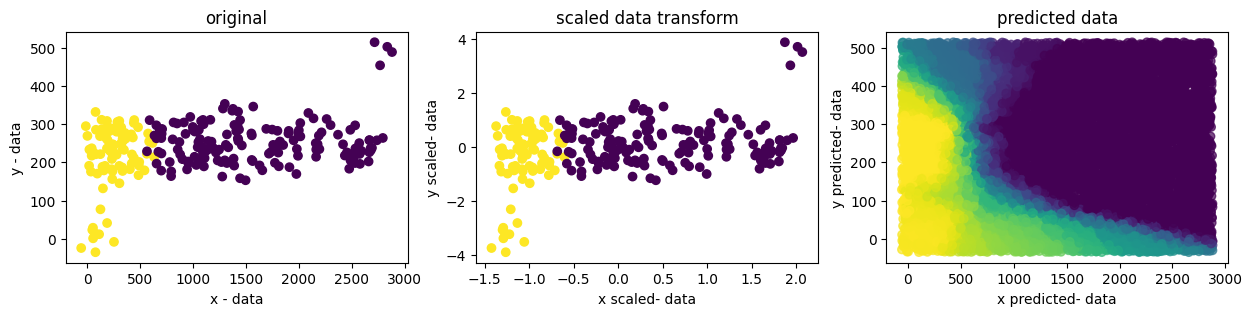

In [127]:
# lets see the how the prediction varys for standard scaller.


plot_output(X, y, sklearn.preprocessing.StandardScaler())

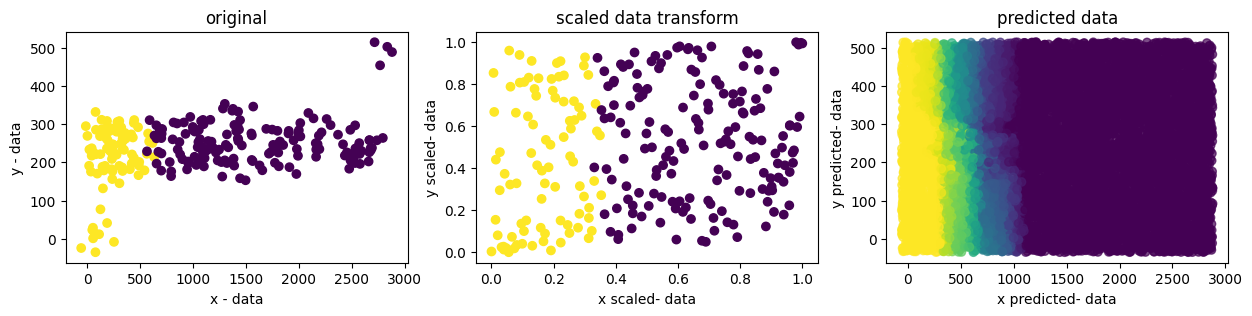

In [129]:
# lets see how the prediction vary of the quantile transformer
# here we have 252 training data. but the default value of quantile transformer is 1000. so we need to set it under the number of sample of our training data.

qtransformer = sklearn.preprocessing.QuantileTransformer(n_quantiles = 100)

plot_output(X, y, qtransformer)